In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("fmcg_sales.csv")

In [3]:
df.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
0,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.1,1,167.84,151.06,248,0,11,S008,7.53,0.182
1,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,125.88,125.88,238,0,6,S057,5.19,0.505
2,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.3,1,398.62,279.03,238,0,6,S017,5.59,0.168
3,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,83.92,83.92,216,0,7,S012,7.81,0.255
4,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.2,1,178.33,142.66,372,0,8,S038,7.62,0.073


In [4]:
df.shape

(1100000, 33)

In [5]:
df.columns

Index(['date', 'year', 'month', 'day', 'weekofyear', 'weekday', 'is_weekend',
       'is_holiday', 'temperature', 'rain_mm', 'store_id', 'country', 'city',
       'channel', 'latitude', 'longitude', 'sku_id', 'sku_name', 'category',
       'subcategory', 'brand', 'units_sold', 'list_price', 'discount_pct',
       'promo_flag', 'gross_sales', 'net_sales', 'stock_on_hand',
       'stock_out_flag', 'lead_time_days', 'supplier_id', 'purchase_cost',
       'margin_pct'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100000 entries, 0 to 1099999
Data columns (total 33 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            1100000 non-null  object 
 1   year            1100000 non-null  int64  
 2   month           1100000 non-null  int64  
 3   day             1100000 non-null  int64  
 4   weekofyear      1100000 non-null  int64  
 5   weekday         1100000 non-null  int64  
 6   is_weekend      1100000 non-null  int64  
 7   is_holiday      1100000 non-null  int64  
 8   temperature     1100000 non-null  float64
 9   rain_mm         1100000 non-null  float64
 10  store_id        1100000 non-null  object 
 11  country         1100000 non-null  object 
 12  city            1100000 non-null  object 
 13  channel         1100000 non-null  object 
 14  latitude        1100000 non-null  float64
 15  longitude       1100000 non-null  float64
 16  sku_id          1100000 non-null  ob

In [9]:
df.isnull().sum()

date              0
year              0
month             0
day               0
weekofyear        0
weekday           0
is_weekend        0
is_holiday        0
temperature       0
rain_mm           0
store_id          0
country           0
city              0
channel           0
latitude          0
longitude         0
sku_id            0
sku_name          0
category          0
subcategory       0
brand             0
units_sold        0
list_price        0
discount_pct      0
promo_flag        0
gross_sales       0
net_sales         0
stock_on_hand     0
stock_out_flag    0
lead_time_days    0
supplier_id       0
purchase_cost     0
margin_pct        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["date"] = pd.to_datetime(df["date"])

In [12]:
df["date"].min(), df["date"].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2023-12-31 00:00:00'))

In [13]:
df["sku_id"].nunique()

102

In [14]:
df["store_id"].nunique()

13

In [15]:
df["country"].nunique()

7

In [16]:
df["city"].nunique()

9

In [17]:
df["supplier_id"].nunique()

60

In [18]:
df["category"].unique()

array(['Personal Care', 'Beverages', 'Dairy', 'Snacks', 'Home Care'],
      dtype=object)

In [19]:
df["subcategory"].unique()

array(['Shampoo', 'Water', 'Yogurt', 'Chocolate', 'Soda', 'Detergent',
       'Cheese', 'Juice', 'Soap', 'Milk', 'Energy drink', 'Chips',
       'Biscuits', 'Cleaner', 'Softener', 'Nuts', 'Toothpaste'],
      dtype=object)

In [20]:
df["channel"].unique()

array(['Hypermarket', 'Supermarket', 'E-commerce', 'Convenience'],
      dtype=object)

In [21]:
df[[
    "units_sold",
    "list_price",
    "discount_pct",
    "gross_sales",
    "net_sales",
    "stock_on_hand",
    "stock_out_flag",
    "lead_time_days",
    "purchase_cost",
    "margin_pct"
]].describe()

,units_sold,list_price,discount_pct,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,purchase_cost,margin_pct
count,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06,1.100000e+06
mean,5.919635e+01,7.712100e+00,1.496241e-02,4.406806e+02,4.299513e+02,2.994757e+02,3.010364e-02,6.500404e+00,4.625546e+00,3.852405e-01
std,4.500722e+01,4.253023e+00,5.477955e-02,4.418005e+02,4.224992e+02,8.007292e+01,1.708726e-01,2.014065e+00,2.662604e+00,1.024581e-01
min,0.000000e+00,1.080000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.900000e-01,-5.000000e-02
25%,2.500000e+01,4.200000e+00,0.000000e+00,1.324400e+02,1.307675e+02,2.450000e+02,0.000000e+00,5.000000e+00,2.400000e+00,3.120000e-01
50%,4.900000e+01,7.380000e+00,0.000000e+00,2.828800e+02,2.778600e+02,3.000000e+02,0.000000e+00,6.000000e+00,4.350000e+00,3.890000e-01
75%,8.200000e+01,1.165000e+01,0.000000e+00,6.052800e+02,5.934600e+02,3.540000e+02,0.000000e+00,8.000000e+00,6.770000e+00,4.690000e-01
max,7.040000e+02,1.480000e+01,3.000000e-01,6.593900e+03,5.144940e+03,6.980000e+02,1.000000e+00,1.700000e+01,1.110000e+01,5.500000e-01


In [22]:
df["stock_out_flag"].value_counts()

stock_out_flag
0    1066886
1      33114
Name: count, dtype: int64

In [23]:
df["stock_out_flag"].value_counts(normalize=True) * 100

stock_out_flag
0    96.989636
1     3.010364
Name: proportion, dtype: float64

In [24]:
df["units_sold"].min()

np.int64(0)

In [25]:
df["stock_on_hand"].min()

np.int64(0)

In [26]:
df["discount_pct"].min(), df["discount_pct"].max()

(np.float64(0.0), np.float64(0.3))

In [27]:
df["lead_time_days"].min(), df["lead_time_days"].max()

(np.int64(1), np.int64(17))

In [28]:
df["purchase_cost"].min()

np.float64(0.49)

In [29]:
df.groupby(["date", "store_id", "sku_id"]).size().value_counts()

1    1100000
Name: count, dtype: int64

In [30]:
df.groupby(["store_id", "sku_id"])["date"].agg(["min", "max", "count"]).head(20)

min        max  count
store_id  sku_id                              
STORE0001 SKU0001 2021-01-01 2023-12-31   1095
          SKU0002 2021-01-01 2023-12-31   1095
          SKU0004 2021-01-01 2023-12-31   1095
          SKU0006 2021-01-01 2023-12-31   1095
          SKU0007 2021-01-01 2023-12-31   1095
          SKU0008 2021-01-01 2023-12-31   1095
          SKU0010 2021-01-01 2023-12-31   1095
          SKU0011 2021-01-01 2023-12-31   1095
          SKU0012 2021-01-01 2023-12-31   1095
          SKU0014 2021-01-01 2023-12-31   1095
          SKU0015 2021-01-01 2023-12-31   1095
          SKU0016 2021-01-01 2023-12-31   1095
          SKU0017 2021-01-01 2023-12-31   1095
          SKU0018 2021-01-01 2023-12-31   1095
          SKU0019 2021-01-01 2023-12-31   1095
          SKU0020 2021-01-01 2023-12-31   1095
          SKU0021 2021-01-01 2023-12-31   1095
          SKU0023 2021-01-01 2023-12-31   1095
          SKU0024 2021-01-01 2023-12-31   1095
          SKU0026 2021-01-01 2023-12-31   1095

In [31]:
df.groupby(["store_id", "sku_id"]).size().value_counts()

1095    1004
620        1
Name: count, dtype: int64

In [32]:
df.groupby(["store_id", "sku_id"]).size().sort_values().head()

store_id   sku_id 
STORE0013  SKU0073     620
           SKU0071    1095
           SKU0068    1095
           SKU0065    1095
           SKU0063    1095
dtype: int64

In [33]:
df[
    (df["store_id"] == "STORE00013") &
    (df["sku_id"] == "SKU0073")
]["date"].agg(["min", "max", "count"])

min      NaT
max      NaT
count      0
Name: date, dtype: object

In [34]:
df[
    (df["store_id"] == "STORE00013") &
    (df["sku_id"] == "SKU0073")
].sort_values("date").head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct


In [35]:
df[
    (df["store_id"] == "STORE00013") &
    (df["sku_id"] == "SKU0073")
].sort_values("date").tail()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct


In [36]:
incomplete = df.groupby(["store_id", "sku_id"]).size().sort_values().index[0]

incomplete

('STORE0013', 'SKU0073')

In [37]:
store, sku = incomplete

df[
    (df["store_id"] == store) &
    (df["sku_id"] == sku)
]["date"].agg(["min", "max", "count"])

min      2021-01-01 00:00:00
max      2022-09-12 00:00:00
count                    620
Name: date, dtype: object

In [38]:
df[
    (df["store_id"] == store) &
    (df["sku_id"] == sku)
].sort_values("date").head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
1099380,2021-01-01,2021,1,1,53,4,0,1,8.44,1.24,...,0.0,0,34.93,34.93,340,0,7,S024,2.98,0.403
1099381,2021-01-02,2021,1,2,53,5,1,0,12.61,1.12,...,0.0,0,39.92,39.92,327,0,10,S059,2.35,0.529
1099382,2021-01-03,2021,1,3,53,6,1,0,12.02,2.69,...,0.0,0,34.93,34.93,259,0,8,S035,3.52,0.295
1099383,2021-01-04,2021,1,4,1,0,0,0,7.76,4.65,...,0.0,0,24.95,24.95,141,0,4,S024,3.52,0.294
1099384,2021-01-05,2021,1,5,1,1,0,0,11.16,1.77,...,0.0,0,24.95,24.95,294,0,3,S012,3.08,0.384


In [39]:
df[
    (df["store_id"] == store) &
    (df["sku_id"] == sku)
].sort_values("date").tail()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,discount_pct,promo_flag,gross_sales,net_sales,stock_on_hand,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct
1099995,2022-09-08,2022,9,8,36,3,0,0,12.36,0.05,...,0.0,0,29.94,29.94,233,0,1,S023,3.07,0.384
1099996,2022-09-09,2022,9,9,36,4,0,0,12.51,5.96,...,0.0,0,34.93,34.93,219,0,7,S028,2.53,0.493
1099997,2022-09-10,2022,9,10,36,5,1,0,12.98,6.26,...,0.0,0,44.91,44.91,305,0,10,S027,2.46,0.507
1099998,2022-09-11,2022,9,11,36,6,1,0,16.72,0.20,...,0.0,0,24.95,24.95,282,0,9,S058,2.92,0.414
1099999,2022-09-12,2022,9,12,37,0,0,0,13.41,3.60,...,0.0,0,29.94,29.94,206,0,3,S051,2.87,0.425


In [40]:
df["calculated_gross_sales"] = df["units_sold"] * df["list_price"]

(df["calculated_gross_sales"] - df["gross_sales"]).abs().describe()

count    1.100000e+06
mean     1.580949e-14
std      4.280046e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.552714e-15
max      9.094947e-13
dtype: float64

In [41]:
df["calculated_net_sales"] = (
    df["gross_sales"] * (1 - df["discount_pct"])
)

(df["calculated_net_sales"] - df["net_sales"]).abs().describe()

count    1.100000e+06
mean     1.773355e-04
std      7.664113e-04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.000000e-03
dtype: float64

In [42]:
df.drop(columns=["calculated_gross_sales", "calculated_net_sales"], inplace=True)

In [43]:
pd.crosstab(df["stock_out_flag"], df["stock_on_hand"] == 0)

stock_on_hand,False,True
stock_out_flag,,
0,1066782,104
1,33110,4


In [44]:
df.groupby("stock_out_flag")["stock_on_hand"].describe()

,count,mean,std,min,25%,50%,75%,max
stock_out_flag,,,,,,,,
0,1066886.0,299.462723,80.073036,0.0,245.0,300.0,354.0,698.0
1,33114.0,299.892613,80.069358,0.0,246.0,300.0,354.0,647.0


In [45]:
pd.crosstab(
    df["stock_out_flag"],
    df["units_sold"] == 0
)

units_sold,False,True
stock_out_flag,,
0,1066328,558
1,30580,2534


In [46]:
df.groupby("stock_out_flag")["units_sold"].describe()

,count,mean,std,min,25%,50%,75%,max
stock_out_flag,,,,,,,,
0,1066886.0,60.670839,44.848599,0.0,27.0,50.0,83.0,704.0
1,33114.0,11.690312,12.569304,0.0,3.0,8.0,16.0,154.0


In [47]:
for col in ["country", "city", "channel", "category", "subcategory", "brand"]:
    print(f"\n{col}:")
    print(df[col].unique())


country:
['Germany' 'Italy' 'Poland' 'France' 'Spain' 'Austria' 'Netherlands']

city:
['Berlin' 'Rome' 'Milan' 'Warsaw' 'Paris' 'Barcelona' 'Vienna' 'Madrid'
 'Amsterdam']

channel:
['Hypermarket' 'Supermarket' 'E-commerce' 'Convenience']

category:
['Personal Care' 'Beverages' 'Dairy' 'Snacks' 'Home Care']

subcategory:
['Shampoo' 'Water' 'Yogurt' 'Chocolate' 'Soda' 'Detergent' 'Cheese'
 'Juice' 'Soap' 'Milk' 'Energy drink' 'Chips' 'Biscuits' 'Cleaner'
 'Softener' 'Nuts' 'Toothpaste']

brand:
['BrandB' 'BrandD' 'BrandA' 'BrandF' 'BrandC' 'BrandE']


### Time-Series Coverage Check
### There is only one Store × SKU combination with incomplete sales history of 620 days.
### The combination is STORE00013 + SKU0073.
### The available data for this combination ranges from 2021-01-01 to 2022-09-12.
### The remaining 1,004 Store × SKU combinations have the complete 1,095 days (3 years) of data.
### This incomplete combination will be handled separately during forecasting/model building rather than assuming the missing dates represent zero sales.

# Exploratory Data Analysis (EDA)

#### 1) What does our daily demand (units_sold) look like?

In [49]:
df["units_sold"].describe()

count    1.100000e+06
mean     5.919635e+01
std      4.500722e+01
min      0.000000e+00
25%      2.500000e+01
50%      4.900000e+01
75%      8.200000e+01
max      7.040000e+02
Name: units_sold, dtype: float64

In [50]:
df["units_sold"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01      3.0
0.05     10.0
0.25     25.0
0.50     49.0
0.75     82.0
0.95    142.0
0.99    209.0
Name: units_sold, dtype: float64

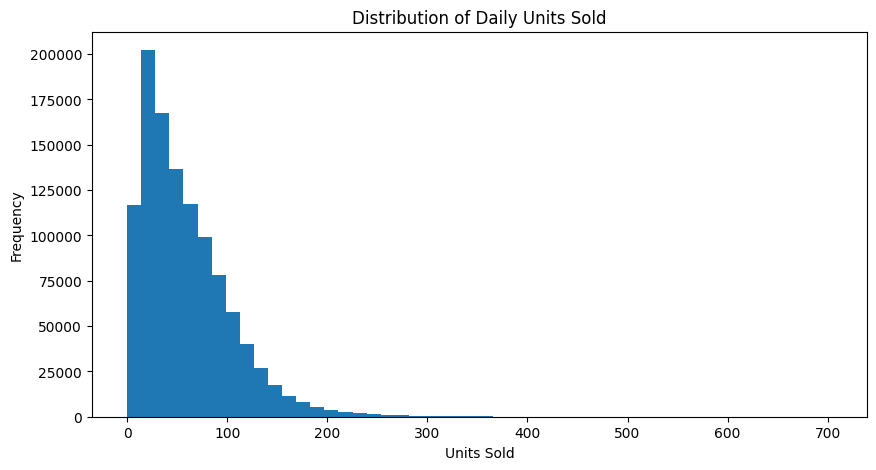

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df["units_sold"], bins=50)

plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Units Sold")

plt.show()

#### 2)Next: Demand Trend Over Time

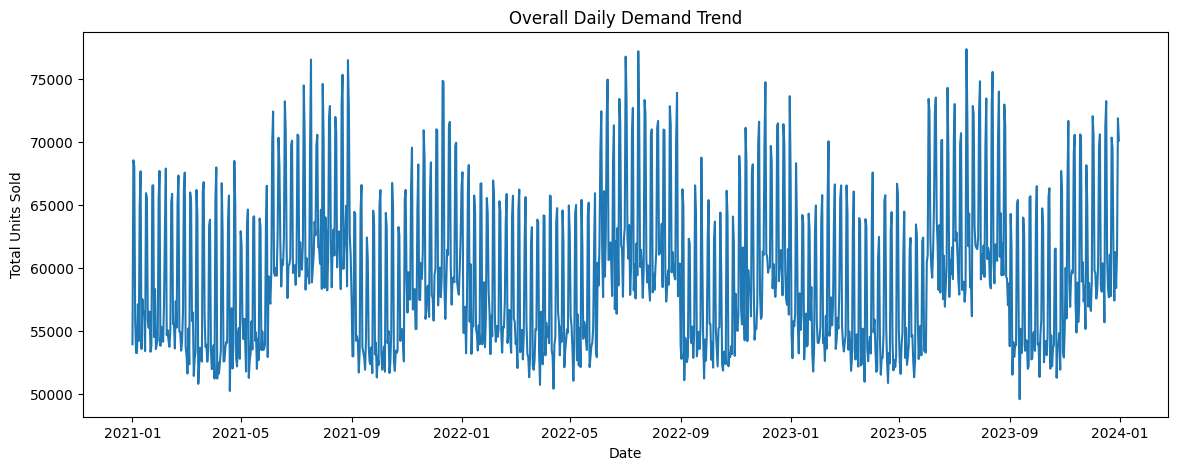

In [52]:
daily_demand = df.groupby("date")["units_sold"].sum()

plt.figure(figsize=(14, 5))

plt.plot(daily_demand)

plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.title("Overall Daily Demand Trend")

plt.show()

#### 3)Smooth the Demand Series

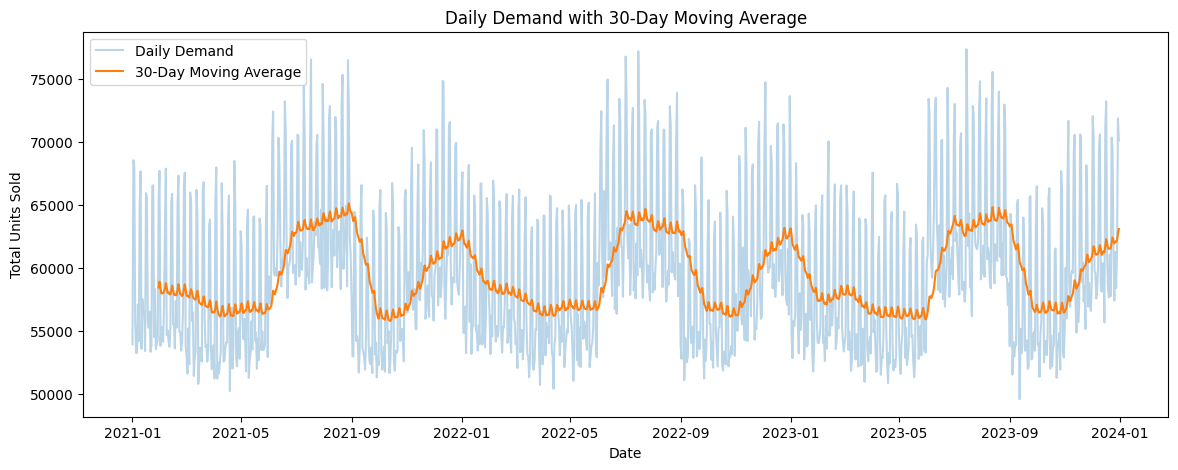

In [53]:
daily_demand_30d = daily_demand.rolling(window=30).mean()

plt.figure(figsize=(14, 5))

plt.plot(daily_demand, alpha=0.3, label="Daily Demand")
plt.plot(daily_demand_30d, label="30-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.title("Daily Demand with 30-Day Moving Average")
plt.legend()

plt.show()

#### 4) Product-Level Analysis

In [55]:
sku_demand = (
    df.groupby("sku_id")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

sku_demand.head(15)

sku_id
SKU0001    1792381
SKU0006    1662175
SKU0035    1455704
SKU0096    1286230
SKU0028    1253907
SKU0017    1243211
SKU0099    1242389
SKU0027    1200897
SKU0034    1190066
SKU0018    1173032
SKU0013    1134258
SKU0046    1105834
SKU0070    1101644
SKU0004    1098948
SKU0005    1096500
Name: units_sold, dtype: int64

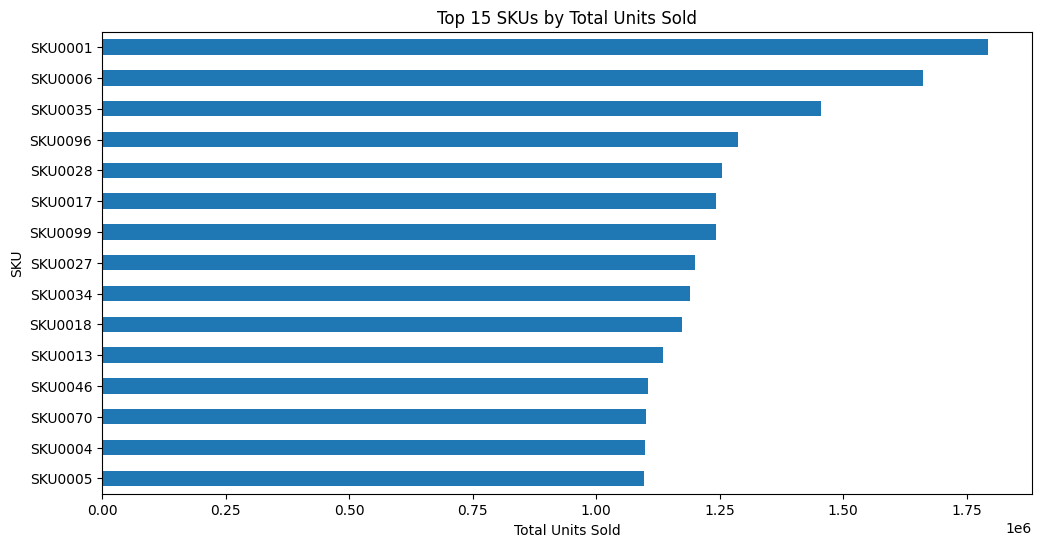

In [56]:
plt.figure(figsize=(12, 6))

sku_demand.head(15).sort_values().plot(kind="barh")

plt.xlabel("Total Units Sold")
plt.ylabel("SKU")
plt.title("Top 15 SKUs by Total Units Sold")

plt.show()

#### 5) Category-Level Demand

In [57]:
category_demand = (
    df.groupby("category")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

category_demand

category
Beverages        18090386
Snacks           16724604
Personal Care    10799580
Dairy            10224202
Home Care         9277210
Name: units_sold, dtype: int64

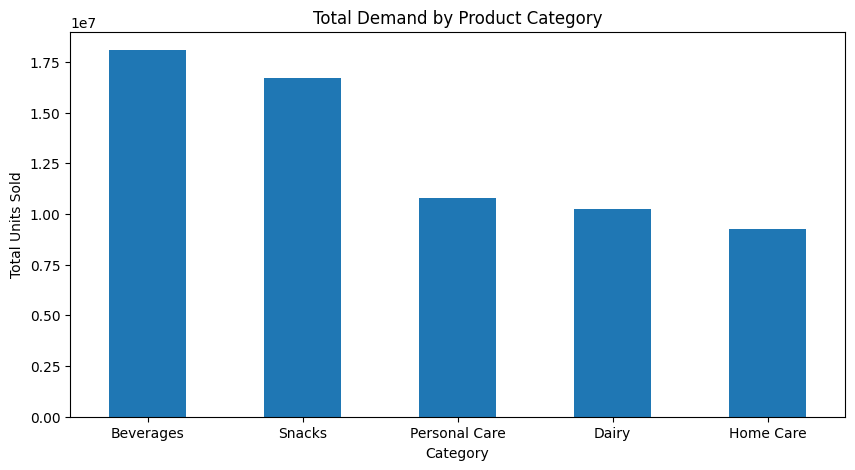

In [60]:
plt.figure(figsize=(10, 5))

category_demand.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.title("Total Demand by Product Category")

plt.xticks(rotation=0)

plt.show()

#### 6) Country-Level Demand

In [61]:
country_demand = (
    df.groupby("country")["units_sold"]
      .sum()
      .sort_values(ascending=False)
)

country_demand

country
Italy          19361774
Spain          14668017
Germany        11738571
France          6014974
Poland          5860180
Austria         5742174
Netherlands     1730292
Name: units_sold, dtype: int64

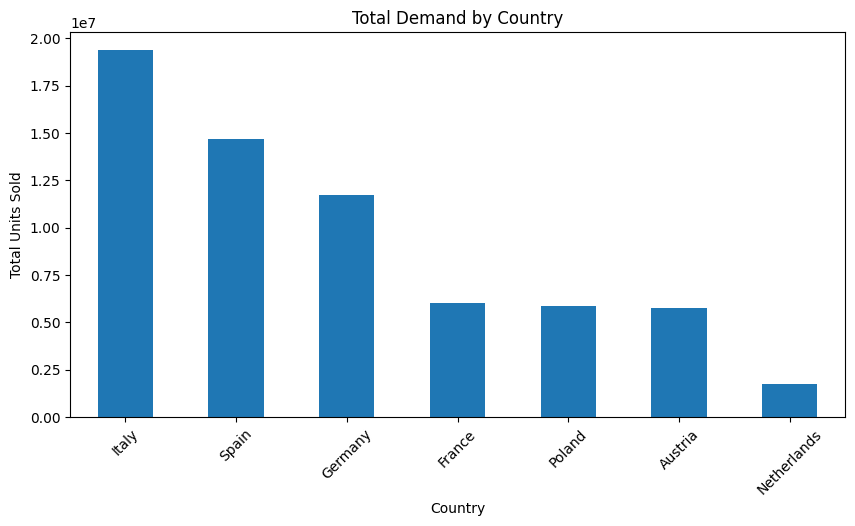

In [62]:
plt.figure(figsize=(10, 5))

country_demand.plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Total Units Sold")
plt.title("Total Demand by Country")

plt.xticks(rotation=45)

plt.show()

In [63]:
country_analysis = df.groupby("country").agg(
    total_demand=("units_sold", "sum"),
    number_of_stores=("store_id", "nunique")
)

country_analysis["demand_per_store"] = (
    country_analysis["total_demand"] / country_analysis["number_of_stores"]
)

country_analysis.sort_values("total_demand", ascending=False)

,total_demand,number_of_stores,demand_per_store
country,,,
Italy,19361774,4,4840443.5
Spain,14668017,3,4889339.0
Germany,11738571,2,5869285.5
France,6014974,1,6014974.0
Poland,5860180,1,5860180.0
Austria,5742174,1,5742174.0
Netherlands,1730292,1,1730292.0


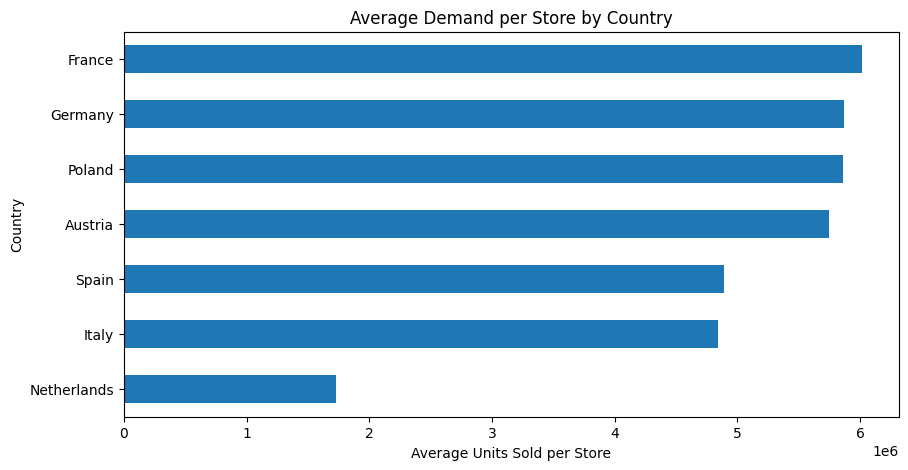

In [64]:
plt.figure(figsize=(10, 5))

country_analysis["demand_per_store"].sort_values().plot(kind="barh")

plt.xlabel("Average Units Sold per Store")
plt.ylabel("Country")
plt.title("Average Demand per Store by Country")

plt.show()

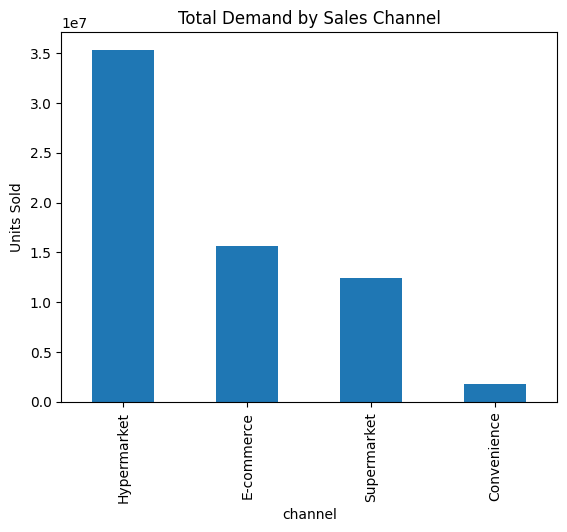

In [65]:
channel_demand = df.groupby("channel")["units_sold"].sum().sort_values(ascending=False)

channel_demand.plot(kind="bar")
plt.title("Total Demand by Sales Channel")
plt.ylabel("Units Sold")
plt.show()

# Demand Forecasting

In [67]:
sample = df[
    (df["store_id"] == "STORE00001") &
    (df["sku_id"] == "SKU00001")
].copy()

sample = sample.sort_values("date")

sample[["date", "store_id", "sku_id", "units_sold"]].head()

,date,store_id,sku_id,units_sold


In [68]:
sample.shape

(0, 33)

In [69]:
sample[["date", "units_sold"]].tail()

,date,units_sold


In [70]:
# Find Store × SKU combinations with complete 3-year history
complete_pairs = (
    df.groupby(["store_id", "sku_id"])
      .size()
      .reset_index(name="days")
)

complete_pairs = complete_pairs[complete_pairs["days"] == 1095]

complete_pairs.head()

,store_id,sku_id,days
0,STORE0001,SKU0001,1095
1,STORE0001,SKU0002,1095
2,STORE0001,SKU0004,1095
3,STORE0001,SKU0006,1095
4,STORE0001,SKU0007,1095


In [71]:
store, sku = complete_pairs.iloc[0][["store_id", "sku_id"]]

print("Selected Store:", store)
print("Selected SKU:", sku)

Selected Store: STORE0001
Selected SKU: SKU0001


In [72]:
sample = df[
    (df["store_id"] == store) &
    (df["sku_id"] == sku)
].copy()

sample = sample.sort_values("date")

print(sample.shape)
print(sample[["date", "store_id", "sku_id", "units_sold"]].head())
print(sample[["date", "units_sold"]].tail())

(1095, 33)
            date   store_id   sku_id  units_sold
54750 2021-01-01  STORE0001  SKU0001          81
54751 2021-01-02  STORE0001  SKU0001         134
54752 2021-01-03  STORE0001  SKU0001         257
54753 2021-01-04  STORE0001  SKU0001         284
54754 2021-01-05  STORE0001  SKU0001          92
            date  units_sold
55840 2023-12-27          88
55841 2023-12-28         162
55842 2023-12-29         126
55843 2023-12-30         120
55844 2023-12-31         106


In [73]:
train = sample.iloc[:-90].copy()
test = sample.iloc[-90:].copy()

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

Training data: (1005, 33)
Testing data: (90, 33)

Training period:
2021-01-01 00:00:00 to 2023-10-02 00:00:00

Testing period:
2023-10-03 00:00:00 to 2023-12-31 00:00:00


#### Model 1 — Naive Forecast (Tomorrow's demand will be the same as today's demand.)

In [74]:
test["naive_forecast"] = sample["units_sold"].shift(1).loc[test.index]

In [75]:
test[["date", "units_sold", "naive_forecast"]].head(10)

,date,units_sold,naive_forecast
55755,2023-10-03,102,128.0
55756,2023-10-04,93,102.0
55757,2023-10-05,102,93.0
55758,2023-10-06,82,102.0
55759,2023-10-07,171,82.0
55760,2023-10-08,141,171.0
55761,2023-10-09,60,141.0
55762,2023-10-10,101,60.0
55763,2023-10-11,126,101.0
55764,2023-10-12,109,126.0


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_naive = mean_absolute_error(
    test["units_sold"],
    test["naive_forecast"]
)

rmse_naive = np.sqrt(
    mean_squared_error(
        test["units_sold"],
        test["naive_forecast"]
    )
)

print("Naive Forecast MAE:", mae_naive)
print("Naive Forecast RMSE:", rmse_naive)

Naive Forecast MAE: 62.577777777777776
Naive Forecast RMSE: 84.60338842702066


#### Model 2 — Moving Average Forecast

In [78]:
train_values = train["units_sold"].tolist()

moving_avg_forecast = []

for i in range(len(test)):
    last_7_days = train_values[-7:]
    forecast = np.mean(last_7_days)
    moving_avg_forecast.append(forecast)
    train_values.append(test["units_sold"].iloc[i])

test["ma7_forecast"] = moving_avg_forecast

In [79]:
test[["date", "units_sold", "ma7_forecast"]].head(10)

,date,units_sold,ma7_forecast
55755,2023-10-03,102,122.142857
55756,2023-10-04,93,117.000000
55757,2023-10-05,102,117.571429
55758,2023-10-06,82,94.000000
55759,2023-10-07,171,95.142857
55760,2023-10-08,141,102.857143
55761,2023-10-09,60,117.000000
55762,2023-10-10,101,107.285714
55763,2023-10-11,126,107.142857
55764,2023-10-12,109,111.857143


In [80]:
mae_ma7 = mean_absolute_error(
    test["units_sold"],
    test["ma7_forecast"]
)

rmse_ma7 = np.sqrt(
    mean_squared_error(
        test["units_sold"],
        test["ma7_forecast"]
    )
)

print("7-Day Moving Average MAE:", mae_ma7)
print("7-Day Moving Average RMSE:", rmse_ma7)

7-Day Moving Average MAE: 49.304761904761904
7-Day Moving Average RMSE: 65.81170143182345


#### Model 3 — Exponential Moving Average

In [82]:
# Combine training and test demand
all_demand = pd.concat([
    train["units_sold"],
    test["units_sold"]
])

# Calculate 7-day EMA
ema = all_demand.ewm(span=7, adjust=False).mean()

# Use yesterday's EMA as today's forecast
test["ema_forecast"] = ema.shift(1).loc[test.index]

test[["date", "units_sold", "ema_forecast"]].head(10)

,date,units_sold,ema_forecast
55755,2023-10-03,102,112.526815
55756,2023-10-04,93,109.895111
55757,2023-10-05,102,105.671333
55758,2023-10-06,82,104.753500
55759,2023-10-07,171,99.065125
55760,2023-10-08,141,117.048844
55761,2023-10-09,60,123.036633
55762,2023-10-10,101,107.277475
55763,2023-10-11,126,105.708106
55764,2023-10-12,109,110.781079


In [83]:
mae_ema = mean_absolute_error(
    test["units_sold"],
    test["ema_forecast"]
)

rmse_ema = np.sqrt(
    mean_squared_error(
        test["units_sold"],
        test["ema_forecast"]
    )
)

print("EMA MAE:", mae_ema)
print("EMA RMSE:", rmse_ema)

EMA MAE: 49.269287900565
EMA RMSE: 66.1139284278633


#### Model 4 — Machine Learning Forecast

In [84]:
ml_data = sample.copy()

# Lag features
ml_data["lag_1"] = ml_data["units_sold"].shift(1)
ml_data["lag_7"] = ml_data["units_sold"].shift(7)
ml_data["lag_14"] = ml_data["units_sold"].shift(14)

# Rolling average of previous 7 days
ml_data["rolling_7"] = (
    ml_data["units_sold"]
    .shift(1)
    .rolling(7)
    .mean()
)

# Calendar features
ml_data["month"] = ml_data["date"].dt.month
ml_data["day_of_week"] = ml_data["date"].dt.dayofweek
ml_data["is_weekend"] = ml_data["is_weekend"].astype(int)

# Remove rows where lag/rolling features are unavailable
ml_data = ml_data.dropna()

ml_data.head()

,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,stock_out_flag,lead_time_days,supplier_id,purchase_cost,margin_pct,lag_1,lag_7,lag_14,rolling_7,day_of_week
54764,2021-01-15,2021,1,15,2,4,0,0,13.33,0.00,...,0,5,S048,3.81,0.389,144.0,97.0,81.0,122.857143,4
54765,2021-01-16,2021,1,16,2,5,1,0,10.01,7.62,...,0,7,S042,3.50,0.439,128.0,98.0,134.0,127.285714,5
54766,2021-01-17,2021,1,17,2,6,1,0,14.80,5.24,...,0,5,S034,3.67,0.312,152.0,29.0,257.0,135.000000,6
54767,2021-01-18,2021,1,18,3,0,0,0,8.06,0.66,...,0,5,S026,3.43,0.351,161.0,89.0,284.0,153.857143,0
54768,2021-01-19,2021,1,19,3,1,0,0,13.01,5.84,...,0,2,S041,2.85,0.543,152.0,214.0,92.0,162.857143,1


In [85]:
ml_data.drop(columns=["day_of_week"], inplace=True)

In [86]:
ml_data[
    [
        "date",
        "units_sold",
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_7",
        "month",
        "weekday",
        "is_weekend",
        "is_holiday",
        "promo_flag",
        "discount_pct",
        "temperature",
        "rain_mm"
    ]
].head()

,date,units_sold,lag_1,lag_7,lag_14,rolling_7,month,weekday,is_weekend,is_holiday,promo_flag,discount_pct,temperature,rain_mm
54764,2021-01-15,128,144.0,97.0,81.0,122.857143,1,4,0,0,0,0.0,13.33,0.00
54765,2021-01-16,152,128.0,98.0,134.0,127.285714,1,5,1,0,0,0.0,10.01,7.62
54766,2021-01-17,161,152.0,29.0,257.0,135.000000,1,6,1,0,1,0.1,14.80,5.24
54767,2021-01-18,152,161.0,89.0,284.0,153.857143,1,0,0,0,1,0.1,8.06,0.66
54768,2021-01-19,44,152.0,214.0,92.0,162.857143,1,1,0,0,0,0.0,13.01,5.84


In [87]:
ml_train = ml_data[ml_data["date"] < "2023-10-03"].copy()
ml_test = ml_data[ml_data["date"] >= "2023-10-03"].copy()

print("ML Training:", ml_train.shape)
print("ML Testing:", ml_test.shape)

ML Training: (991, 37)
ML Testing: (90, 37)


In [88]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "month",
    "weekday",
    "is_weekend",
    "is_holiday",
    "promo_flag",
    "discount_pct",
    "temperature",
    "rain_mm"
]

X_train = ml_train[features]
y_train = ml_train["units_sold"]

X_test = ml_test[features]
y_test = ml_test["units_sold"]

In [89]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [90]:
rf_predictions = rf_model.predict(X_test)

test["rf_forecast"] = rf_predictions

test[["date", "units_sold", "rf_forecast"]].head(10)

,date,units_sold,rf_forecast
55755,2023-10-03,102,104.488417
55756,2023-10-04,93,103.206817
55757,2023-10-05,102,119.627473
55758,2023-10-06,82,112.000427
55759,2023-10-07,171,127.450107
55760,2023-10-08,141,103.761296
55761,2023-10-09,60,103.049172
55762,2023-10-10,101,109.294155
55763,2023-10-11,126,115.405897
55764,2023-10-12,109,113.876926


In [91]:
mae_rf = mean_absolute_error(
    y_test,
    test["rf_forecast"]
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        test["rf_forecast"]
    )
)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 37.58693196472153
Random Forest RMSE: 48.24419901594602


In [92]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values(ascending=False)

feature_importance

rolling_7       0.234924
discount_pct    0.188910
promo_flag      0.155196
temperature     0.067836
month           0.063153
rain_mm         0.060332
lag_7           0.059639
lag_1           0.059129
lag_14          0.053901
weekday         0.040176
is_weekend      0.016025
is_holiday      0.000780
dtype: float64

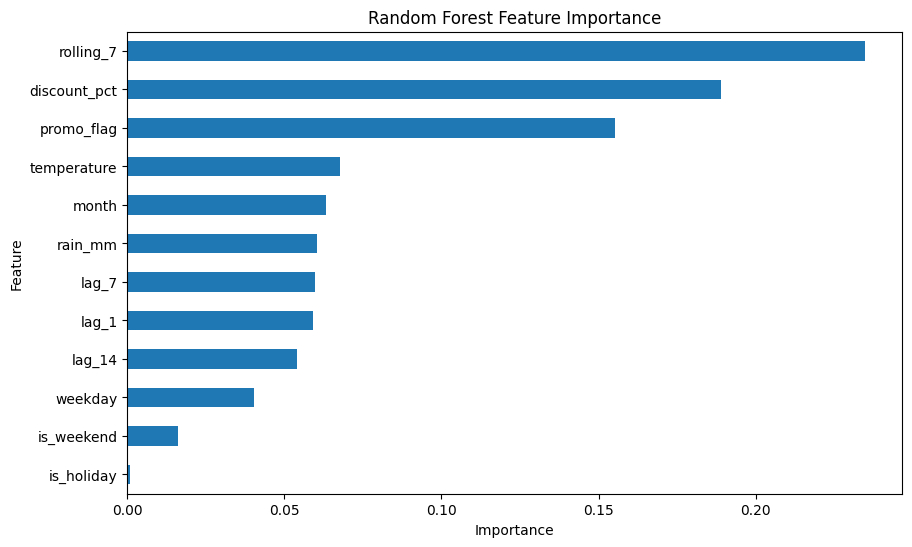

In [93]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.show()

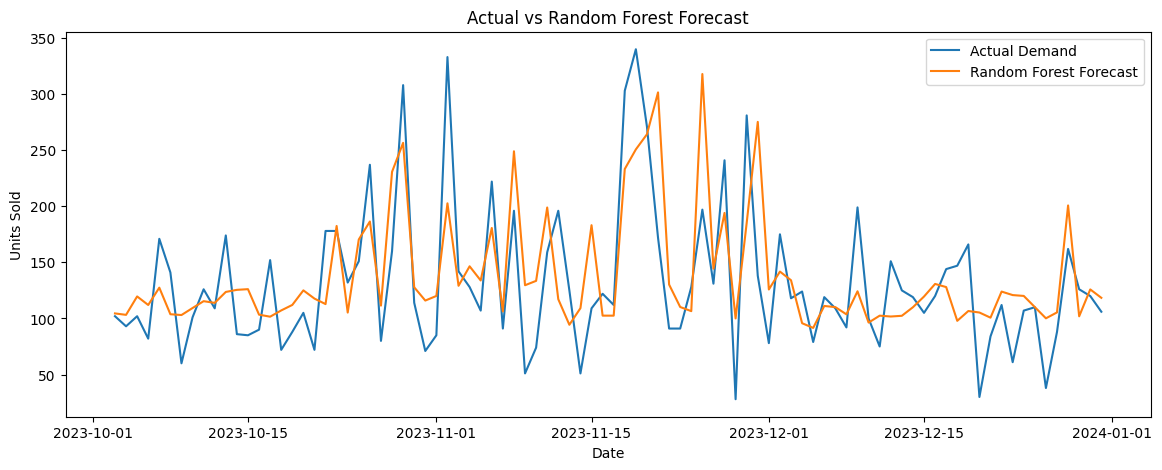

In [94]:
plt.figure(figsize=(14, 5))

plt.plot(test["date"], test["units_sold"], label="Actual Demand")
plt.plot(test["date"], test["rf_forecast"], label="Random Forest Forecast")

plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.title("Actual vs Random Forest Forecast")
plt.legend()

plt.show()

#### Validating Models Across Multiple Store × SKU Combinations

In [98]:
# Select 10 complete Store × SKU combinations
validation_pairs = complete_pairs.head(10)[["store_id", "sku_id"]]

validation_pairs

,store_id,sku_id
0,STORE0001,SKU0001
1,STORE0001,SKU0002
2,STORE0001,SKU0004
3,STORE0001,SKU0006
4,STORE0001,SKU0007
5,STORE0001,SKU0008
6,STORE0001,SKU0010
7,STORE0001,SKU0011
8,STORE0001,SKU0012
9,STORE0001,SKU0014


In [99]:
validation_results = []

In [100]:
for _, pair in validation_pairs.iterrows():

    store = pair["store_id"]
    sku = pair["sku_id"]

    # Get one Store × SKU time series
    data = df[
        (df["store_id"] == store) &
        (df["sku_id"] == sku)
    ].sort_values("date").copy()

    # Last 90 days as test set
    train_data = data.iloc[:-90].copy()
    test_data = data.iloc[-90:].copy()

    # -------------------------
    # Naive Forecast
    # -------------------------
    test_data["naive"] = test_data["units_sold"].shift(1)

    # First test-day forecast = last training-day demand
    test_data.iloc[0, test_data.columns.get_loc("naive")] = (
        train_data["units_sold"].iloc[-1]
    )

    # -------------------------
    # 7-Day Moving Average
    # -------------------------
    history = train_data["units_sold"].tolist()
    ma_predictions = []

    for i in range(len(test_data)):
        prediction = np.mean(history[-7:])
        ma_predictions.append(prediction)

        # Add actual demand after prediction
        history.append(test_data["units_sold"].iloc[i])

    test_data["ma7"] = ma_predictions

    # -------------------------
    # ML Features
    # -------------------------
    ml = data.copy()

    ml["lag_1"] = ml["units_sold"].shift(1)
    ml["lag_7"] = ml["units_sold"].shift(7)
    ml["lag_14"] = ml["units_sold"].shift(14)

    ml["rolling_7"] = (
        ml["units_sold"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    ml["month"] = ml["date"].dt.month

    ml = ml.dropna()

    # Same 90-day test period
    ml_train = ml.iloc[:-90]
    ml_test = ml.iloc[-90:]

    features_validation = [
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_7",
        "month",
        "weekday",
        "is_weekend",
        "is_holiday",
        "promo_flag",
        "discount_pct",
        "temperature",
        "rain_mm"
    ]

    X_train_v = ml_train[features_validation]
    y_train_v = ml_train["units_sold"]

    X_test_v = ml_test[features_validation]
    y_test_v = ml_test["units_sold"]

    # -------------------------
    # Random Forest
    # -------------------------
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_v, y_train_v)

    rf_pred = rf.predict(X_test_v)

    # -------------------------
    # Store results
    # -------------------------
    validation_results.append({
        "store_id": store,
        "sku_id": sku,

        "naive_mae": mean_absolute_error(
            test_data["units_sold"],
            test_data["naive"]
        ),

        "ma7_mae": mean_absolute_error(
            test_data["units_sold"],
            test_data["ma7"]
        ),

        "rf_mae": mean_absolute_error(
            y_test_v,
            rf_pred
        ),

        "naive_rmse": np.sqrt(
            mean_squared_error(
                test_data["units_sold"],
                test_data["naive"]
            )
        ),

        "ma7_rmse": np.sqrt(
            mean_squared_error(
                test_data["units_sold"],
                test_data["ma7"]
            )
        ),

        "rf_rmse": np.sqrt(
            mean_squared_error(
                y_test_v,
                rf_pred
            )
        )
    })

In [101]:
validation_results_df = pd.DataFrame(validation_results)

validation_results_df

,store_id,sku_id,naive_mae,ma7_mae,rf_mae,naive_rmse,ma7_rmse,rf_rmse
0,STORE0001,SKU0001,62.577778,49.304762,37.586932,84.603388,65.811701,48.244199
1,STORE0001,SKU0002,24.488889,20.049206,18.114329,32.210074,25.496338,23.977207
2,STORE0001,SKU0004,35.033333,27.166667,24.104112,44.058673,34.454963,30.790521
3,STORE0001,SKU0006,64.477778,45.747619,34.716024,81.709581,59.990946,43.207732
4,STORE0001,SKU0007,11.522222,8.760317,7.800444,14.315881,11.381341,10.084436
5,STORE0001,SKU0008,8.844444,6.793651,5.842424,11.148493,8.758566,7.557936
6,STORE0001,SKU0010,19.788889,15.723810,11.221441,25.400131,20.283154,14.508611
7,STORE0001,SKU0011,11.966667,9.647619,6.247400,14.899292,11.752898,7.969159
8,STORE0001,SKU0012,35.366667,24.528571,15.600455,47.187451,34.056645,20.660503
9,STORE0001,SKU0014,22.122222,17.187302,17.070288,28.885406,21.701615,21.969138


In [102]:
validation_pairs_cross = (
    complete_pairs
    .groupby("store_id")
    .first()
    .reset_index()[["store_id", "sku_id"]]
)

validation_pairs_cross

,store_id,sku_id
0,STORE0001,SKU0001
1,STORE0002,SKU0001
2,STORE0003,SKU0001
3,STORE0004,SKU0001
4,STORE0005,SKU0001
5,STORE0006,SKU0001
6,STORE0007,SKU0001
7,STORE0008,SKU0001
8,STORE0009,SKU0001
9,STORE0010,SKU0001


In [103]:
validation_results_cross = []

In [104]:
for _, pair in validation_pairs_cross.iterrows():

    store = pair["store_id"]
    sku = pair["sku_id"]

    # Get one Store × SKU time series
    data = df[
        (df["store_id"] == store) &
        (df["sku_id"] == sku)
    ].sort_values("date").copy()

    # Last 90 days as test set
    train_data = data.iloc[:-90].copy()
    test_data = data.iloc[-90:].copy()

    # -------------------------
    # Naive Forecast
    # -------------------------
    test_data["naive"] = test_data["units_sold"].shift(1)

    # First test-day forecast = last training-day demand
    test_data.iloc[0, test_data.columns.get_loc("naive")] = (
        train_data["units_sold"].iloc[-1]
    )

    # -------------------------
    # 7-Day Moving Average
    # -------------------------
    history = train_data["units_sold"].tolist()
    ma_predictions = []

    for i in range(len(test_data)):
        prediction = np.mean(history[-7:])
        ma_predictions.append(prediction)

        # Add actual demand after prediction
        history.append(test_data["units_sold"].iloc[i])

    test_data["ma7"] = ma_predictions

    # -------------------------
    # ML Features
    # -------------------------
    ml = data.copy()

    ml["lag_1"] = ml["units_sold"].shift(1)
    ml["lag_7"] = ml["units_sold"].shift(7)
    ml["lag_14"] = ml["units_sold"].shift(14)

    ml["rolling_7"] = (
        ml["units_sold"]
        .shift(1)
        .rolling(7)
        .mean()
    )

    ml["month"] = ml["date"].dt.month

    ml = ml.dropna()

    # Same 90-day test period
    ml_train = ml.iloc[:-90]
    ml_test = ml.iloc[-90:]

    features_validation = [
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_7",
        "month",
        "weekday",
        "is_weekend",
        "is_holiday",
        "promo_flag",
        "discount_pct",
        "temperature",
        "rain_mm"
    ]

    X_train_v = ml_train[features_validation]
    y_train_v = ml_train["units_sold"]

    X_test_v = ml_test[features_validation]
    y_test_v = ml_test["units_sold"]

    # -------------------------
    # Random Forest
    # -------------------------
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train_v, y_train_v)

    rf_pred = rf.predict(X_test_v)

    # -------------------------
    # Store results
    # -------------------------
    validation_results_cross.append({
        "store_id": store,
        "sku_id": sku,

        "naive_mae": mean_absolute_error(
            test_data["units_sold"],
            test_data["naive"]
        ),

        "ma7_mae": mean_absolute_error(
            test_data["units_sold"],
            test_data["ma7"]
        ),

        "rf_mae": mean_absolute_error(
            y_test_v,
            rf_pred
        ),

        "naive_rmse": np.sqrt(
            mean_squared_error(
                test_data["units_sold"],
                test_data["naive"]
            )
        ),

        "ma7_rmse": np.sqrt(
            mean_squared_error(
                test_data["units_sold"],
                test_data["ma7"]
            )
        ),

        "rf_rmse": np.sqrt(
            mean_squared_error(
                y_test_v,
                rf_pred
            )
        )
    })

In [105]:
validation_results_cross_df = pd.DataFrame(validation_results_cross)

validation_results_cross_df

,store_id,sku_id,naive_mae,ma7_mae,rf_mae,naive_rmse,ma7_rmse,rf_rmse
0,STORE0001,SKU0001,62.577778,49.304762,37.586932,84.603388,65.811701,48.244199
1,STORE0002,SKU0001,43.077778,36.555556,25.184941,60.247360,46.861992,33.422476
2,STORE0003,SKU0001,41.600000,32.131746,23.385851,55.931108,42.927553,32.355305
3,STORE0004,SKU0001,57.844444,49.198413,34.996371,81.706657,67.274338,46.973548
4,STORE0005,SKU0001,71.911111,52.330159,41.847491,97.945336,70.689612,57.002093
5,STORE0006,SKU0001,71.133333,53.296825,35.530345,93.451711,72.733173,50.408250
6,STORE0007,SKU0001,50.455556,38.009524,27.430241,65.654567,49.526896,36.453861
7,STORE0008,SKU0001,65.911111,51.546032,36.703110,90.381414,70.425184,50.778592
8,STORE0009,SKU0001,56.866667,43.841270,36.805949,78.705781,62.420772,49.483174
9,STORE0010,SKU0001,52.811111,41.007937,27.866634,67.566346,55.200490,38.392707


In [106]:
print("Average MAE")
print("Naive:", validation_results_cross_df["naive_mae"].mean())
print("7-Day MA:", validation_results_cross_df["ma7_mae"].mean())
print("Random Forest:", validation_results_cross_df["rf_mae"].mean())

print("\nAverage RMSE")
print("Naive:", validation_results_cross_df["naive_rmse"].mean())
print("7-Day MA:", validation_results_cross_df["ma7_rmse"].mean())
print("Random Forest:", validation_results_cross_df["rf_rmse"].mean())

Average MAE
Naive: 55.86752136752137
7-Day MA: 43.29023199023199
Random Forest: 32.66299818456611

Average RMSE
Naive: 75.27479720599345
7-Day MA: 58.02652908775278
Random Forest: 43.77366643643969


# Global Random Forest Forecasting

In [114]:
global_data = df.merge(
    complete_pairs[["store_id", "sku_id"]],
    on=["store_id", "sku_id"],
    how="inner"
)

global_data = global_data.sort_values(
    ["store_id", "sku_id", "date"]
).copy()

print("Global dataset shape:", global_data.shape)
print("Store × SKU combinations:", 
      global_data[["store_id", "sku_id"]].drop_duplicates().shape[0])

Global dataset shape: (1099380, 33)
Store × SKU combinations: 1004


In [115]:
global_data["lag_1"] = (
    global_data
    .groupby(["store_id", "sku_id"])["units_sold"]
    .shift(1)
)

global_data["lag_7"] = (
    global_data
    .groupby(["store_id", "sku_id"])["units_sold"]
    .shift(7)
)

global_data["lag_14"] = (
    global_data
    .groupby(["store_id", "sku_id"])["units_sold"]
    .shift(14)
)

global_data["rolling_7"] = (
    global_data
    .groupby(["store_id", "sku_id"])["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [117]:
global_data[
    [
        "store_id",
        "sku_id",
        "date",
        "units_sold",
        "lag_1",
        "lag_7",
        "lag_14",
        "rolling_7",
        "month",
        "weekday",
        "is_weekend",
        "is_holiday",
        "promo_flag",
        "discount_pct",
        "temperature",
        "rain_mm"
    ]
].head(10)

,store_id,sku_id,date,units_sold,lag_1,lag_7,lag_14,rolling_7,month,weekday,is_weekend,is_holiday,promo_flag,discount_pct,temperature,rain_mm
54750,STORE0001,SKU0001,2021-01-01,81,NaN,NaN,NaN,NaN,1,4,0,1,0,0.00,8.44,1.24
54751,STORE0001,SKU0001,2021-01-02,134,81.0,NaN,NaN,NaN,1,5,1,0,1,0.20,12.61,1.12
54752,STORE0001,SKU0001,2021-01-03,257,134.0,NaN,NaN,NaN,1,6,1,0,1,0.15,12.02,2.69
54753,STORE0001,SKU0001,2021-01-04,284,257.0,NaN,NaN,NaN,1,0,0,0,1,0.15,7.76,4.65
54754,STORE0001,SKU0001,2021-01-05,92,284.0,NaN,NaN,NaN,1,1,0,0,0,0.00,11.16,1.77
54755,STORE0001,SKU0001,2021-01-06,53,92.0,NaN,NaN,NaN,1,2,0,0,0,0.00,13.29,1.46
54756,STORE0001,SKU0001,2021-01-07,252,53.0,NaN,NaN,NaN,1,3,0,0,1,0.15,6.19,11.58
54757,STORE0001,SKU0001,2021-01-08,97,252.0,81.0,NaN,164.714286,1,4,0,0,0,0.00,13.00,2.90
54758,STORE0001,SKU0001,2021-01-09,98,97.0,134.0,NaN,167.000000,1,5,1,0,0,0.00,9.56,0.26
54759,STORE0001,SKU0001,2021-01-10,29,98.0,257.0,NaN,161.857143,1,6,1,0,0,0.00,13.42,0.72


In [118]:
global_data = global_data.dropna().copy()

print("Shape after removing lag rows:", global_data.shape)

Shape after removing lag rows: (1085324, 37)


In [119]:
global_data[
    ["store_id", "sku_id", "date", "units_sold",
     "lag_1", "lag_7", "lag_14", "rolling_7"]
].head()

,store_id,sku_id,date,units_sold,lag_1,lag_7,lag_14,rolling_7
54764,STORE0001,SKU0001,2021-01-15,128,144.0,97.0,81.0,122.857143
54765,STORE0001,SKU0001,2021-01-16,152,128.0,98.0,134.0,127.285714
54766,STORE0001,SKU0001,2021-01-17,161,152.0,29.0,257.0,135.000000
54767,STORE0001,SKU0001,2021-01-18,152,161.0,89.0,284.0,153.857143
54768,STORE0001,SKU0001,2021-01-19,44,152.0,214.0,92.0,162.857143


In [120]:
global_train = global_data[
    global_data["date"] < "2023-10-03"
].copy()

global_test = global_data[
    global_data["date"] >= "2023-10-03"
].copy()

print("Training data:", global_train.shape)
print("Testing data:", global_test.shape)

print("\nTraining period:")
print(global_train["date"].min(), "to", global_train["date"].max())

print("\nTesting period:")
print(global_test["date"].min(), "to", global_test["date"].max())

Training data: (994964, 37)
Testing data: (90360, 37)

Training period:
2021-01-15 00:00:00 to 2023-10-02 00:00:00

Testing period:
2023-10-03 00:00:00 to 2023-12-31 00:00:00


In [121]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "month",
    "weekday",
    "is_weekend",
    "is_holiday",
    "promo_flag",
    "discount_pct",
    "temperature",
    "rain_mm",
    "store_id",
    "sku_id"
]

X_train = global_train[features]
y_train = global_train["units_sold"]

X_test = global_test[features]
y_test = global_test["units_sold"]

In [122]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["store_id", "sku_id"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [123]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (994964, 127)
Encoded testing shape: (90360, 127)


In [124]:
global_rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

global_rf.fit(X_train_encoded, y_train)

RandomForestRegressor(max_depth=10, n_estimators=150, n_jobs=-1,
                      random_state=42)

In [125]:
global_predictions = global_rf.predict(X_test_encoded)

global_test["rf_forecast"] = global_predictions

global_test[
    ["date", "store_id", "sku_id", "units_sold", "rf_forecast"]
].head(10)

,date,store_id,sku_id,units_sold,rf_forecast
55755,2023-10-03,STORE0001,SKU0001,102,96.254899
55756,2023-10-04,STORE0001,SKU0001,93,97.650166
55757,2023-10-05,STORE0001,SKU0001,102,93.867046
55758,2023-10-06,STORE0001,SKU0001,82,86.968489
55759,2023-10-07,STORE0001,SKU0001,171,98.803282
55760,2023-10-08,STORE0001,SKU0001,141,108.846580
55761,2023-10-09,STORE0001,SKU0001,60,99.847910
55762,2023-10-10,STORE0001,SKU0001,101,93.404713
55763,2023-10-11,STORE0001,SKU0001,126,89.021354
55764,2023-10-12,STORE0001,SKU0001,109,98.401201


In [126]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

global_mae = mean_absolute_error(
    global_test["units_sold"],
    global_test["rf_forecast"]
)

global_rmse = np.sqrt(
    mean_squared_error(
        global_test["units_sold"],
        global_test["rf_forecast"]
    )
)

print("Global Random Forest MAE:", global_mae)
print("Global Random Forest RMSE:", global_rmse)

Global Random Forest MAE: 17.103077708349673
Global Random Forest RMSE: 25.85361216535849


In [127]:
global_test["forecast_error"] = (
    global_test["units_sold"] - global_test["rf_forecast"]
)

uncertainty = (
    global_test
    .groupby(["store_id", "sku_id"])["forecast_error"]
    .agg(
        mean_error="mean",
        error_std="std",
        mae=lambda x: np.mean(np.abs(x))
    )
    .reset_index()
)

uncertainty.head(10)

,store_id,sku_id,mean_error,error_std,mae
0,STORE0001,SKU0001,5.415339,42.877211,34.155282
1,STORE0001,SKU0002,0.372936,23.985865,18.325071
2,STORE0001,SKU0004,9.856286,30.491863,25.372477
3,STORE0001,SKU0006,12.401749,44.410625,36.112556
4,STORE0001,SKU0007,0.293639,10.218557,7.751796
5,STORE0001,SKU0008,0.266942,7.936037,6.047380
6,STORE0001,SKU0010,-4.092617,16.480867,13.553886
7,STORE0001,SKU0011,-2.295470,8.239607,6.909293
8,STORE0001,SKU0012,-6.250844,25.064371,19.325018
9,STORE0001,SKU0014,1.120691,20.910580,16.331386


In [128]:
uncertainty["error_std"].describe()

count    1004.000000
mean       21.942334
std        13.002214
min         1.847814
25%        10.397398
50%        21.052488
75%        30.876913
max        71.514156
Name: error_std, dtype: float64

In [129]:
uncertainty["mae"].describe()

count    1004.000000
mean       17.103078
std        10.103284
min         1.497935
25%         8.037921
50%        16.473104
75%        23.933217
max        51.788807
Name: mae, dtype: float64

In [130]:
global_test.groupby(
    ["store_id", "sku_id"]
).size().describe()

count    1004.0
mean       90.0
std         0.0
min        90.0
25%        90.0
50%        90.0
75%        90.0
max        90.0
dtype: float64

# Inventory Optimization

In [132]:
# Average forecasted daily demand for each Store × SKU
forecast_summary = (
    global_test
    .groupby(["store_id", "sku_id"])["rf_forecast"]
    .mean()
    .reset_index(name="avg_daily_forecast")
)

# Average lead time for each Store × SKU
lead_time_summary = (
    global_data
    .groupby(["store_id", "sku_id"])["lead_time_days"]
    .mean()
    .reset_index(name="avg_lead_time")
)

# Combine everything
inventory_policy = uncertainty.merge(
    forecast_summary,
    on=["store_id", "sku_id"]
).merge(
    lead_time_summary,
    on=["store_id", "sku_id"]
)

inventory_policy.head(10)

,store_id,sku_id,mean_error,error_std,mae,avg_daily_forecast,avg_lead_time
0,STORE0001,SKU0001,5.415339,42.877211,34.155282,125.962439,6.584644
1,STORE0001,SKU0002,0.372936,23.985865,18.325071,69.782620,6.447734
2,STORE0001,SKU0004,9.856286,30.491863,25.372477,96.632603,6.564292
3,STORE0001,SKU0006,12.401749,44.410625,36.112556,118.042695,6.511563
4,STORE0001,SKU0007,0.293639,10.218557,7.751796,29.684139,6.508788
5,STORE0001,SKU0008,0.266942,7.936037,6.047380,28.588613,6.573543
6,STORE0001,SKU0010,-4.092617,16.480867,13.553886,50.214840,6.418131
7,STORE0001,SKU0011,-2.295470,8.239607,6.909293,28.417693,6.512488
8,STORE0001,SKU0012,-6.250844,25.064371,19.325018,62.906399,6.506938
9,STORE0001,SKU0014,1.120691,20.910580,16.331386,65.079309,6.491212


In [133]:
z = 1.645   # 95% service level

inventory_policy["safety_stock"] = (
    z
    * inventory_policy["error_std"]
    * np.sqrt(inventory_policy["avg_lead_time"])
)

inventory_policy[
    [
        "store_id",
        "sku_id",
        "avg_daily_forecast",
        "error_std",
        "avg_lead_time",
        "safety_stock"
    ]
].head(10)

,store_id,sku_id,avg_daily_forecast,error_std,avg_lead_time,safety_stock
0,STORE0001,SKU0001,125.962439,42.877211,6.584644,180.991663
1,STORE0001,SKU0002,69.782620,23.985865,6.447734,100.190104
2,STORE0001,SKU0004,96.632603,30.491863,6.564292,128.512040
3,STORE0001,SKU0006,118.042695,44.410625,6.511563,186.421255
4,STORE0001,SKU0007,29.684139,10.218557,6.508788,42.885014
5,STORE0001,SKU0008,28.588613,7.936037,6.573543,33.471049
6,STORE0001,SKU0010,50.214840,16.480867,6.418131,68.683159
7,STORE0001,SKU0011,28.417693,8.239607,6.512488,34.589628
8,STORE0001,SKU0012,62.906399,25.064371,6.506938,105.174642
9,STORE0001,SKU0014,65.079309,20.910580,6.491212,87.638489


In [134]:
inventory_policy["lead_time_demand"] = (
    inventory_policy["avg_daily_forecast"]
    * inventory_policy["avg_lead_time"]
)

inventory_policy["reorder_point"] = (
    inventory_policy["lead_time_demand"]
    + inventory_policy["safety_stock"]
)

inventory_policy[
    [
        "store_id",
        "sku_id",
        "avg_daily_forecast",
        "avg_lead_time",
        "lead_time_demand",
        "safety_stock",
        "reorder_point"
    ]
].head(10)

,store_id,sku_id,avg_daily_forecast,avg_lead_time,lead_time_demand,safety_stock,reorder_point
0,STORE0001,SKU0001,125.962439,6.584644,829.417797,180.991663,1010.409460
1,STORE0001,SKU0002,69.782620,6.447734,449.939741,100.190104,550.129845
2,STORE0001,SKU0004,96.632603,6.564292,634.324654,128.512040,762.836694
3,STORE0001,SKU0006,118.042695,6.511563,768.642490,186.421255,955.063745
4,STORE0001,SKU0007,29.684139,6.508788,193.207771,42.885014,236.092785
5,STORE0001,SKU0008,28.588613,6.573543,187.928478,33.471049,221.399528
6,STORE0001,SKU0010,50.214840,6.418131,322.285437,68.683159,390.968596
7,STORE0001,SKU0011,28.417693,6.512488,185.069895,34.589628,219.659523
8,STORE0001,SKU0012,62.906399,6.506938,409.328041,105.174642,514.502683
9,STORE0001,SKU0014,65.079309,6.491212,422.443584,87.638489,510.082072


In [135]:
inventory_policy[
    [
        "avg_daily_forecast",
        "avg_lead_time",
        "safety_stock",
        "reorder_point"
    ]
].describe()

,avg_daily_forecast,avg_lead_time,safety_stock,reorder_point
count,1004.000000,1004.000000,1004.000000,1004.000000
mean,59.480936,6.500531,92.032980,478.731927
std,32.895289,0.061262,54.563203,267.472423
min,5.325953,6.311748,7.733895,42.212171
25%,28.562665,6.463228,43.641368,229.253963
50%,57.686704,6.500463,88.305691,471.863214
75%,85.599536,6.538390,129.730391,687.868020
max,153.470304,6.705828,300.853299,1260.415389


In [136]:
inventory_policy[
    [
        "store_id",
        "sku_id",
        "avg_daily_forecast",
        "error_std",
        "avg_lead_time",
        "safety_stock",
        "reorder_point"
    ]
].sort_values(
    "safety_stock",
    ascending=False
).head(10)

,store_id,sku_id,avg_daily_forecast,error_std,avg_lead_time,safety_stock,reorder_point
25,STORE0001,SKU0035,146.716636,71.514156,6.540241,300.853299,1260.415389
427,STORE0006,SKU0034,128.446109,70.171836,6.481961,293.888068,1126.470758
827,STORE0011,SKU0034,131.530537,66.052330,6.516189,277.364499,1134.442298
586,STORE0008,SKU0035,143.954114,64.455586,6.617946,272.764651,1225.445255
266,STORE0004,SKU0034,135.172244,63.545567,6.485661,266.212412,1142.893822
346,STORE0005,SKU0034,125.057420,63.008727,6.583719,265.951377,1089.294260
828,STORE0011,SKU0035,144.682692,61.311302,6.568918,258.495718,1208.904408
907,STORE0012,SKU0034,115.048712,61.109902,6.551341,257.301671,1011.025056
267,STORE0004,SKU0035,151.480210,59.534247,6.493987,249.567756,1233.278281
821,STORE0011,SKU0027,132.509518,59.175444,6.543941,249.015915,1116.150354


In [137]:
inventory_policy[
    [
        "store_id",
        "sku_id",
        "avg_daily_forecast",
        "error_std",
        "avg_lead_time",
        "safety_stock",
        "reorder_point"
    ]
].sort_values(
    "safety_stock"
).head(10)

,store_id,sku_id,avg_daily_forecast,error_std,avg_lead_time,safety_stock,reorder_point
996,STORE0013,SKU0086,5.325953,1.847814,6.473636,7.733895,42.212171
968,STORE0013,SKU0015,6.959320,2.175833,6.553191,9.162582,54.768339
138,STORE0002,SKU0073,9.299551,2.564548,6.508788,10.762840,71.291648
147,STORE0002,SKU0086,8.461132,2.627840,6.484736,11.008065,65.876273
546,STORE0007,SKU0086,8.605773,2.603789,6.612396,11.014151,67.918932
534,STORE0007,SKU0073,9.410812,2.655268,6.535615,11.166511,72.671953
220,STORE0003,SKU0073,8.940627,2.744387,6.585569,11.585316,70.464431
707,STORE0009,SKU0086,9.270197,2.813008,6.502313,11.799696,72.077418
891,STORE0012,SKU0015,11.432962,3.002902,6.444033,12.539666,86.214054
173,STORE0003,SKU0015,9.751886,3.045216,6.533765,12.804591,76.521126


## Determining Order Quantity

In [139]:
inventory_policy["order_quantity"] = (
    inventory_policy["avg_daily_forecast"] * 7
)

inventory_policy[
    [
        "store_id",
        "sku_id",
        "avg_daily_forecast",
        "safety_stock",
        "reorder_point",
        "order_quantity"
    ]
].head(10)

,store_id,sku_id,avg_daily_forecast,safety_stock,reorder_point,order_quantity
0,STORE0001,SKU0001,125.962439,180.991663,1010.409460,881.737071
1,STORE0001,SKU0002,69.782620,100.190104,550.129845,488.478338
2,STORE0001,SKU0004,96.632603,128.512040,762.836694,676.428221
3,STORE0001,SKU0006,118.042695,186.421255,955.063745,826.298866
4,STORE0001,SKU0007,29.684139,42.885014,236.092785,207.788972
5,STORE0001,SKU0008,28.588613,33.471049,221.399528,200.120292
6,STORE0001,SKU0010,50.214840,68.683159,390.968596,351.503877
7,STORE0001,SKU0011,28.417693,34.589628,219.659523,198.923848
8,STORE0001,SKU0012,62.906399,105.174642,514.502683,440.344795
9,STORE0001,SKU0014,65.079309,87.638489,510.082072,455.555166


In [140]:
# Merge inventory policy with historical data
simulation_data = global_data.merge(
    inventory_policy[
        [
            "store_id",
            "sku_id",
            "reorder_point",
            "order_quantity",
            "avg_lead_time"
        ]
    ],
    on=["store_id", "sku_id"],
    how="inner"
)

simulation_data = simulation_data.sort_values(
    ["store_id", "sku_id", "date"]
).copy()

print("Simulation data shape:", simulation_data.shape)
print("Store × SKU combinations:", 
      simulation_data[["store_id", "sku_id"]].drop_duplicates().shape[0])

simulation_data.head()

Simulation data shape: (1085324, 40)
Store × SKU combinations: 1004


,date,year,month,day,weekofyear,weekday,is_weekend,is_holiday,temperature,rain_mm,...,supplier_id,purchase_cost,margin_pct,lag_1,lag_7,lag_14,rolling_7,reorder_point,order_quantity,avg_lead_time
0,2021-01-15,2021,1,15,2,4,0,0,13.33,0.00,...,S048,3.81,0.389,144.0,97.0,81.0,122.857143,1010.40946,881.737071,6.584644
1,2021-01-16,2021,1,16,2,5,1,0,10.01,7.62,...,S042,3.50,0.439,128.0,98.0,134.0,127.285714,1010.40946,881.737071,6.584644
2,2021-01-17,2021,1,17,2,6,1,0,14.80,5.24,...,S034,3.67,0.312,152.0,29.0,257.0,135.000000,1010.40946,881.737071,6.584644
3,2021-01-18,2021,1,18,3,0,0,0,8.06,0.66,...,S026,3.43,0.351,161.0,89.0,284.0,153.857143,1010.40946,881.737071,6.584644
4,2021-01-19,2021,1,19,3,1,0,0,13.01,5.84,...,S041,2.85,0.543,152.0,214.0,92.0,162.857143,1010.40946,881.737071,6.584644


In [143]:
# Improved inventory simulation for one Store × SKU

store = "STORE0001"
sku = "SKU0001"

sim = simulation_data[
    (simulation_data["store_id"] == store) &
    (simulation_data["sku_id"] == sku)
].copy()

sim = sim.sort_values("date").copy()

# Policy parameters
rop = sim["reorder_point"].iloc[0]
order_qty = sim["order_quantity"].iloc[0]
lead_time = int(round(sim["avg_lead_time"].iloc[0]))

# Initial inventory
inventory = rop

# Track results
inventory_history = []
inventory_before_history = []
demand_fulfilled_history = []
lost_sales_history = []
stockout_history = []
orders_placed = []
orders_received = []

# Orders currently in transit
pending_orders = []

for _, row in sim.iterrows():

    current_date = row["date"]

    # -----------------------------
    # 1. Receive arriving orders
    # -----------------------------
    arriving_today = sum(
        order["quantity"]
        for order in pending_orders
        if order["arrival_date"] <= current_date
    )

    inventory += arriving_today

    pending_orders = [
        order
        for order in pending_orders
        if order["arrival_date"] > current_date
    ]

    # -----------------------------
    # 2. Record inventory before demand
    # -----------------------------
    inventory_before = inventory

    # -----------------------------
    # 3. Fulfill today's demand
    # -----------------------------
    demand = row["units_sold"]

    demand_fulfilled = min(inventory, demand)

    lost_sales = max(demand - inventory, 0)

    inventory -= demand_fulfilled

    stockout = 1 if lost_sales > 0 else 0

    # -----------------------------
    # 4. Place replenishment order
    # -----------------------------
    order_placed = 0

    if inventory <= rop and len(pending_orders) == 0:

        arrival_date = current_date + pd.Timedelta(days=lead_time)

        pending_orders.append({
            "quantity": order_qty,
            "arrival_date": arrival_date
        })

        order_placed = order_qty

    # -----------------------------
    # 5. Store results
    # -----------------------------
    inventory_before_history.append(inventory_before)
    inventory_history.append(inventory)
    demand_fulfilled_history.append(demand_fulfilled)
    lost_sales_history.append(lost_sales)
    stockout_history.append(stockout)
    orders_placed.append(order_placed)
    orders_received.append(arriving_today)


# Add results to dataframe

sim["inventory_before"] = inventory_before_history
sim["simulated_inventory"] = inventory_history
sim["demand_fulfilled"] = demand_fulfilled_history
sim["lost_sales"] = lost_sales_history
sim["stockout_flag_sim"] = stockout_history
sim["order_placed"] = orders_placed
sim["order_received"] = orders_received


# Display results

sim[
    [
        "date",
        "units_sold",
        "inventory_before",
        "demand_fulfilled",
        "lost_sales",
        "simulated_inventory",
        "stockout_flag_sim",
        "order_placed",
        "order_received"
    ]
].head(20)

,date,units_sold,inventory_before,demand_fulfilled,lost_sales,simulated_inventory,stockout_flag_sim,order_placed,order_received
0,2021-01-15,128,1010.409460,128.0,0.0,882.409460,0,881.737071,0.000000
1,2021-01-16,152,882.409460,152.0,0.0,730.409460,0,0.000000,0.000000
2,2021-01-17,161,730.409460,161.0,0.0,569.409460,0,0.000000,0.000000
3,2021-01-18,152,569.409460,152.0,0.0,417.409460,0,0.000000,0.000000
4,2021-01-19,44,417.409460,44.0,0.0,373.409460,0,0.000000,0.000000
5,2021-01-20,142,373.409460,142.0,0.0,231.409460,0,0.000000,0.000000
6,2021-01-21,114,231.409460,114.0,0.0,117.409460,0,0.000000,0.000000
7,2021-01-22,69,999.146531,69.0,0.0,930.146531,0,881.737071,881.737071
8,2021-01-23,136,930.146531,136.0,0.0,794.146531,0,0.000000,0.000000
9,2021-01-24,121,794.146531,121.0,0.0,673.146531,0,0.000000,0.000000


In [144]:
total_demand = sim["units_sold"].sum()
total_fulfilled = sim["demand_fulfilled"].sum()
total_lost_sales = sim["lost_sales"].sum()

fill_rate = total_fulfilled / total_demand

stockout_days = sim["stockout_flag_sim"].sum()

average_inventory = sim["simulated_inventory"].mean()

number_of_orders = (sim["order_placed"] > 0).sum()

total_units_ordered = sim["order_placed"].sum()

print("Total Demand:", round(total_demand, 2))
print("Demand Fulfilled:", round(total_fulfilled, 2))
print("Lost Sales:", round(total_lost_sales, 2))
print("Fill Rate:", round(fill_rate * 100, 2), "%")
print("Stockout Days:", stockout_days)
print("Average Inventory:", round(average_inventory, 2))
print("Number of Orders:", number_of_orders)
print("Total Units Ordered:", round(total_units_ordered, 2))

Total Demand: 158317
Demand Fulfilled: 134114.76
Lost Sales: 24202.24
Fill Rate: 84.71 %
Stockout Days: 174
Average Inventory: 402.97
Number of Orders: 153
Total Units Ordered: 134905.77


In [145]:
# ============================================================
# INVENTORY SIMULATION FOR ALL STORE × SKU COMBINATIONS
# ============================================================

def simulate_inventory(group):

    group = group.sort_values("date").copy()

    # Policy parameters for this Store × SKU
    rop = group["reorder_point"].iloc[0]
    order_qty = group["order_quantity"].iloc[0]

    # Initial inventory
    inventory = rop

    # Orders currently in transit
    pending_orders = []

    # Metrics
    inventory_history = []
    demand_fulfilled_history = []
    lost_sales_history = []
    stockout_history = []
    orders_placed = []

    for _, row in group.iterrows():

        current_date = row["date"]

        # ------------------------------------------------
        # 1. Receive orders whose lead time has finished
        # ------------------------------------------------

        arriving_today = sum(
            order["quantity"]
            for order in pending_orders
            if order["arrival_date"] <= current_date
        )

        inventory += arriving_today

        # Remove received orders
        pending_orders = [
            order
            for order in pending_orders
            if order["arrival_date"] > current_date
        ]

        # ------------------------------------------------
        # 2. Today's demand
        # ------------------------------------------------

        demand = row["units_sold"]

        demand_fulfilled = min(inventory, demand)

        lost_sales = max(demand - inventory, 0)

        inventory -= demand_fulfilled

        stockout = 1 if lost_sales > 0 else 0

        # ------------------------------------------------
        # 3. Reorder decision
        # ------------------------------------------------

        order_placed = 0

        # Only place a new order if no order is currently
        # in transit and inventory is at/below ROP

        if inventory <= rop and len(pending_orders) == 0:

            # Use ACTUAL lead time on the order date
            lead_time = int(row["lead_time_days"])

            arrival_date = (
                current_date +
                pd.Timedelta(days=lead_time)
            )

            pending_orders.append({
                "quantity": order_qty,
                "arrival_date": arrival_date
            })

            order_placed = order_qty

        # ------------------------------------------------
        # 4. Save daily results
        # ------------------------------------------------

        inventory_history.append(inventory)
        demand_fulfilled_history.append(demand_fulfilled)
        lost_sales_history.append(lost_sales)
        stockout_history.append(stockout)
        orders_placed.append(order_placed)

    # Add simulation results
    group["simulated_inventory"] = inventory_history
    group["demand_fulfilled"] = demand_fulfilled_history
    group["lost_sales"] = lost_sales_history
    group["stockout_flag_sim"] = stockout_history
    group["order_placed"] = orders_placed

    return group

In [146]:
# Run simulation for every Store × SKU

simulation_results = []

for (store, sku), group in simulation_data.groupby(
    ["store_id", "sku_id"]
):

    result = simulate_inventory(group)

    simulation_results.append(result)

simulation_results = pd.concat(
    simulation_results,
    ignore_index=True
)

print("Simulation completed!")
print("Rows:", simulation_results.shape[0])
print(
    "Store × SKU combinations:",
    simulation_results[["store_id", "sku_id"]]
    .drop_duplicates()
    .shape[0]
)

Simulation completed!
Rows: 1085324
Store × SKU combinations: 1004


In [147]:
# ============================================================
# PERFORMANCE METRICS FOR EACH STORE × SKU
# ============================================================

performance = (
    simulation_results
    .groupby(["store_id", "sku_id"])
    .agg(
        total_demand=("units_sold", "sum"),
        demand_fulfilled=("demand_fulfilled", "sum"),
        lost_sales=("lost_sales", "sum"),
        stockout_days=("stockout_flag_sim", "sum"),
        average_inventory=("simulated_inventory", "mean"),
        number_of_orders=("order_placed", lambda x: (x > 0).sum()),
        total_units_ordered=("order_placed", "sum")
    )
    .reset_index()
)

# Fill rate
performance["fill_rate"] = (
    performance["demand_fulfilled"] /
    performance["total_demand"]
)

# Convert to percentage
performance["fill_rate_pct"] = (
    performance["fill_rate"] * 100
)

performance.head(10)

,store_id,sku_id,total_demand,demand_fulfilled,lost_sales,stockout_days,average_inventory,number_of_orders,total_units_ordered,fill_rate,fill_rate_pct
0,STORE0001,SKU0001,158317,134504.707137,23812.292863,166,532.439758,153,134905.771818,0.849591,84.959106
1,STORE0001,SKU0002,89098,75966.315618,13131.684382,146,281.212246,156,76202.620789,0.852615,85.261527
2,STORE0001,SKU0004,123560,103579.926351,19980.073649,180,353.491290,153,103493.517878,0.838297,83.829659
3,STORE0001,SKU0006,159859,126552.491410,33306.508590,240,383.669133,153,126423.726531,0.791651,79.165071
4,STORE0001,SKU0007,36052,30755.548859,5296.451141,154,126.481948,149,30960.556822,0.853089,85.308856
5,STORE0001,SKU0008,33484,29335.841885,4148.158115,143,117.830725,147,29417.682942,0.876115,87.611522
6,STORE0001,SKU0010,55370,50829.023058,4540.976942,107,234.371161,145,50968.062216,0.917988,91.798850
7,STORE0001,SKU0011,32313,28388.607512,3924.392488,123,128.236381,143,28446.110321,0.878551,87.855066
8,STORE0001,SKU0012,66683,60669.946868,6013.053132,95,308.893359,138,60767.581726,0.909826,90.982630
9,STORE0001,SKU0014,76531,65967.915579,10563.084421,157,267.257167,145,66055.499004,0.861976,86.197640


In [148]:
baseline = global_test.copy()

baseline["inventory"] = baseline["stock_on_hand"]

baseline_avg_inventory = baseline["inventory"].mean()

print("Baseline Average Inventory:", round(baseline_avg_inventory, 2))

Baseline Average Inventory: 299.71


In [149]:
print("Optimized Average Inventory:",
      round(performance["average_inventory"].mean(), 2))

print("Optimized Fill Rate:",
      round(performance["fill_rate"].mean() * 100, 2), "%")

print("Optimized Stockout Days:",
      round(performance["stockout_days"].mean(), 2))

Optimized Average Inventory: 284.0
Optimized Fill Rate: 93.19 %
Optimized Stockout Days: 85.93


In [150]:
baseline_total_demand = baseline["units_sold"].sum()

baseline_stockout_days = baseline["stock_out_flag"].sum()

baseline_fill_rate = (
    baseline["units_sold"].sum()
    - baseline["units_sold"].where(
        baseline["stock_out_flag"] == 1, 0
    ).sum()
) / baseline_total_demand

print("Baseline Fill Rate:",
      round(baseline_fill_rate * 100, 2), "%")

print("Baseline Stockout Days:",
      baseline_stockout_days)

Baseline Fill Rate: 99.41 %
Baseline Stockout Days: 2668


In [151]:
top_demand = inventory_policy[
    ["store_id", "sku_id", "avg_daily_forecast", "error_std", "reorder_point"]
].sort_values(
    "avg_daily_forecast",
    ascending=False
)

top_demand.head(10)

,store_id,sku_id,avg_daily_forecast,error_std,reorder_point
428,STORE0006,SKU0035,153.470304,57.524987,1232.844981
267,STORE0004,SKU0035,151.480210,59.534247,1233.278281
347,STORE0005,SKU0035,151.049794,58.769782,1210.599902
25,STORE0001,SKU0035,146.716636,71.514156,1260.415389
828,STORE0011,SKU0035,144.682692,61.311302,1208.904408
586,STORE0008,SKU0035,143.954114,64.455586,1225.445255
908,STORE0012,SKU0035,137.376604,49.534785,1100.481218
266,STORE0004,SKU0034,135.172244,63.545567,1142.893822
743,STORE0010,SKU0035,134.848008,56.449718,1113.188190
260,STORE0004,SKU0027,132.664537,57.449865,1095.356419


In [152]:
high_uncertainty = inventory_policy[
    ["store_id", "sku_id", "avg_daily_forecast", "error_std", "reorder_point"]
].sort_values(
    "error_std",
    ascending=False
)

high_uncertainty.head(10)

,store_id,sku_id,avg_daily_forecast,error_std,reorder_point
25,STORE0001,SKU0035,146.716636,71.514156,1260.415389
427,STORE0006,SKU0034,128.446109,70.171836,1126.470758
827,STORE0011,SKU0034,131.530537,66.052330,1134.442298
586,STORE0008,SKU0035,143.954114,64.455586,1225.445255
266,STORE0004,SKU0034,135.172244,63.545567,1142.893822
346,STORE0005,SKU0034,125.057420,63.008727,1089.294260
828,STORE0011,SKU0035,144.682692,61.311302,1208.904408
907,STORE0012,SKU0034,115.048712,61.109902,1011.025056
267,STORE0004,SKU0035,151.480210,59.534247,1233.278281
821,STORE0011,SKU0027,132.509518,59.175444,1116.150354


In [153]:
from sklearn.preprocessing import MinMaxScaler

priority_data = inventory_policy[
    ["store_id", "sku_id", "avg_daily_forecast", "error_std", "reorder_point"]
].copy()

scaler = MinMaxScaler()

priority_data[["demand_score", "uncertainty_score"]] = scaler.fit_transform(
    priority_data[["avg_daily_forecast", "error_std"]]
)

priority_data["priority_score"] = (
    priority_data["demand_score"] +
    priority_data["uncertainty_score"]
) / 2

priority_data = priority_data.sort_values(
    "priority_score",
    ascending=False
)

priority_data.head(10)

,store_id,sku_id,avg_daily_forecast,error_std,reorder_point,demand_score,uncertainty_score,priority_score
25,STORE0001,SKU0035,146.716636,71.514156,1260.415389,0.954412,1.000000,0.977206
586,STORE0008,SKU0035,143.954114,64.455586,1225.445255,0.935764,0.898680,0.917222
267,STORE0004,SKU0035,151.480210,59.534247,1233.278281,0.986567,0.828039,0.907303
427,STORE0006,SKU0034,128.446109,70.171836,1126.470758,0.831082,0.980732,0.905907
347,STORE0005,SKU0035,151.049794,58.769782,1210.599902,0.983661,0.817066,0.900363
428,STORE0006,SKU0035,153.470304,57.524987,1232.844981,1.000000,0.799198,0.899599
828,STORE0011,SKU0035,144.682692,61.311302,1208.904408,0.940682,0.853547,0.897114
827,STORE0011,SKU0034,131.530537,66.052330,1134.442298,0.851903,0.921600,0.886751
266,STORE0004,SKU0034,135.172244,63.545567,1142.893822,0.876485,0.885618,0.881051
346,STORE0005,SKU0034,125.057420,63.008727,1089.294260,0.808208,0.877912,0.843060


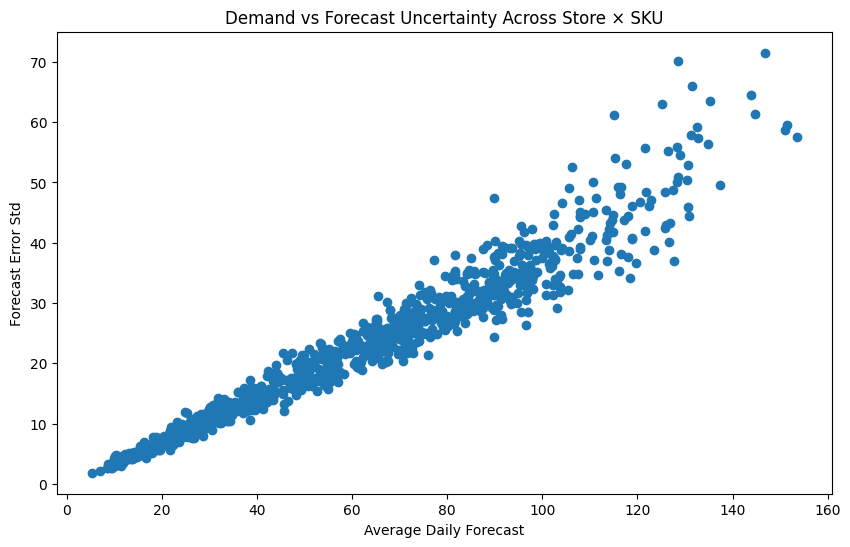

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    priority_data["avg_daily_forecast"],
    priority_data["error_std"]
)

plt.xlabel("Average Daily Forecast")
plt.ylabel("Forecast Error Std")
plt.title("Demand vs Forecast Uncertainty Across Store × SKU")

plt.show()

In [155]:
df.to_csv("raw_sales.csv", index=False)

In [156]:
forecast_results = global_test[
    [
        "store_id",
        "sku_id",
        "date",
        "units_sold",
        "rf_forecast"
    ]
].copy()

forecast_results.to_csv("forecast_results.csv", index=False)

In [157]:
inventory_policy.to_csv("inventory_policy.csv", index=False)

In [158]:
priority_data.to_csv("priority_data.csv", index=False)